In [1]:
from ultralytics import YOLO
from pathlib import Path

model_path = Path(
    "../training/runs/runs/foodlens_yolo11s/weights/best.pt"
)

print("Model exists:", model_path.exists())

model = YOLO(str(model_path))

print("YOLO11s loaded successfully!")

Model exists: True
YOLO11s loaded successfully!


In [3]:
results = model.predict(
    source=r"D:\FoodLens_AI\data\processed\foodlens_20\test\images\004bd4d6cd_jpg.rf.fd3a1f5647555e8ae5a4962436eebe86.jpg",
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

print("========== YOLO11s PREDICTIONS ==========")

total_detections = 0

for result in results:

    if result.boxes is None or len(result.boxes) == 0:
        print("No detections")
        continue

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        food_name = model.names[class_id]

        total_detections += 1

        print(
            f"{total_detections}. "
            f"{food_name} | "
            f"Confidence: {confidence:.2%}"
        )

print("\nTotal detected objects:", total_detections)
print("Ground-truth objects: 5")

========== YOLO11s PREDICTIONS ==========
1. aloo tikki | Confidence: 84.10%
2. aloo tikki | Confidence: 66.17%
3. aloo tikki | Confidence: 54.76%
4. aloo tikki | Confidence: 34.26%

Total detected objects: 4
Ground-truth objects: 5


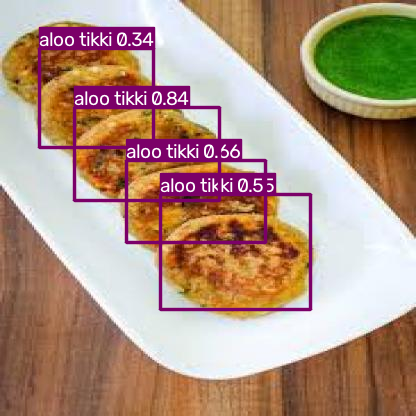

In [4]:
from PIL import Image

result_image = results[0].plot()

display(
    Image.fromarray(result_image[..., ::-1])
)

In [5]:
from ultralytics import YOLO
from pathlib import Path
import random

model_path = Path(
    r"D:\FoodLens_AI\training\runs\runs\foodlens_yolo11s\weights\best.pt"
)

model = YOLO(str(model_path))

print("Model loaded:", model_path.exists())

Model loaded: True


In [6]:
test_dir = Path(
    r"D:\FoodLens_AI\data\processed\foodlens_20\test\images"
)

image_files = list(test_dir.glob("*.jpg"))

print("Total test images:", len(image_files))

random.seed(42)
sample_images = random.sample(image_files, 10)

for i, image in enumerate(sample_images, 1):
    print(i, image.name)

Total test images: 104
1 7effdc5dc6_jpg.rf.9ca4a6bb0bb9c7d3ab2751e84a7dfa20.jpg
2 0dddfcb42d_jpg.rf.bc3f4abb0bd11655bb2c5100218dde6e.jpg
3 01eaebcbec_jpg.rf.eb212d86817311f0ba64ee04edfd4a8e.jpg
4 9e04b2a4ec_jpg.rf.a685321ef28ee15e336bc75482082c6f.jpg
5 29ff2d4476_jpg.rf.3a473f6d1dd6555db4a1ef40201e043a.jpg
6 2243b6e4b7a20baa17fd5d68f5e44b31.jpg
7 1d57fc1de0_jpg.rf.c86cb1f0a30b30de3ab15983d61254c1.jpg
8 10e2670c3b_jpg.rf.4af788564517afe02be8a5d31423d1cc.jpg
9 0dd082619b_jpg.rf.d169a671dc2c553cdbdedacb576d1cdb.jpg
10 8ee25d4267_jpg.rf.f1587507a7a2948d0b933419e85949a1.jpg


In [7]:
results = model.predict(
    source=[str(img) for img in sample_images],
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

print("Prediction completed!")

Prediction completed!


In [8]:
for i, result in enumerate(results, 1):

    print(f"\n========== IMAGE {i} ==========")
    print(sample_images[i-1].name)

    if result.boxes is None or len(result.boxes) == 0:
        print("No detections")
        continue

    for j, box in enumerate(result.boxes, 1):

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        food_name = model.names[class_id]

        print(
            f"{j}. {food_name} | "
            f"{confidence:.2%}"
        )


========== IMAGE 1 ==========
7effdc5dc6_jpg.rf.9ca4a6bb0bb9c7d3ab2751e84a7dfa20.jpg
1. aloo matar | 87.97%
2. aloo matar | 79.49%

========== IMAGE 2 ==========
0dddfcb42d_jpg.rf.bc3f4abb0bd11655bb2c5100218dde6e.jpg
1. kachori | 87.34%
2. kachori | 83.77%
3. kachori | 78.50%
4. kachori | 57.33%
5. kachori | 57.32%
6. kachori | 52.21%

========== IMAGE 3 ==========
01eaebcbec_jpg.rf.eb212d86817311f0ba64ee04edfd4a8e.jpg
1. bhindi masala | 91.64%

========== IMAGE 4 ==========
9e04b2a4ec_jpg.rf.a685321ef28ee15e336bc75482082c6f.jpg
1. palak paneer | 94.78%

========== IMAGE 5 ==========
29ff2d4476_jpg.rf.3a473f6d1dd6555db4a1ef40201e043a.jpg
No detections

========== IMAGE 6 ==========
2243b6e4b7a20baa17fd5d68f5e44b31.jpg
1. chapati | 52.71%
2. dal makhani | 45.72%

========== IMAGE 7 ==========
1d57fc1de0_jpg.rf.c86cb1f0a30b30de3ab15983d61254c1.jpg
1. kadai paneer | 30.86%

========== IMAGE 8 ==========
10e2670c3b_jpg.rf.4af788564517afe02be8a5d31423d1cc.jpg
1. bhatura | 89.92%
2. bhatura

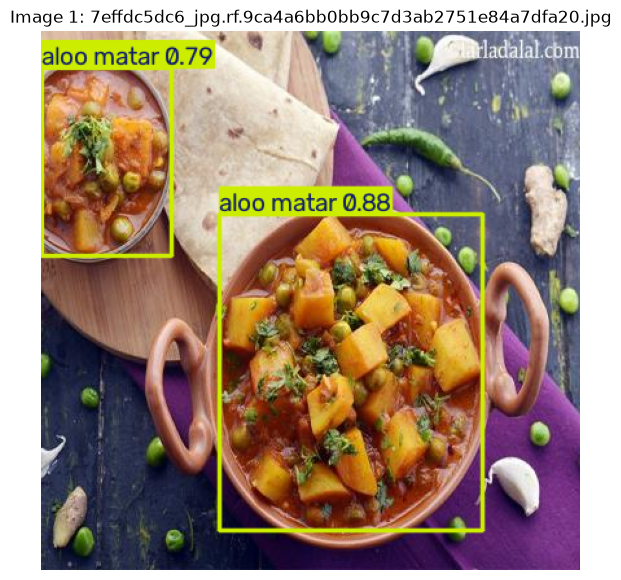

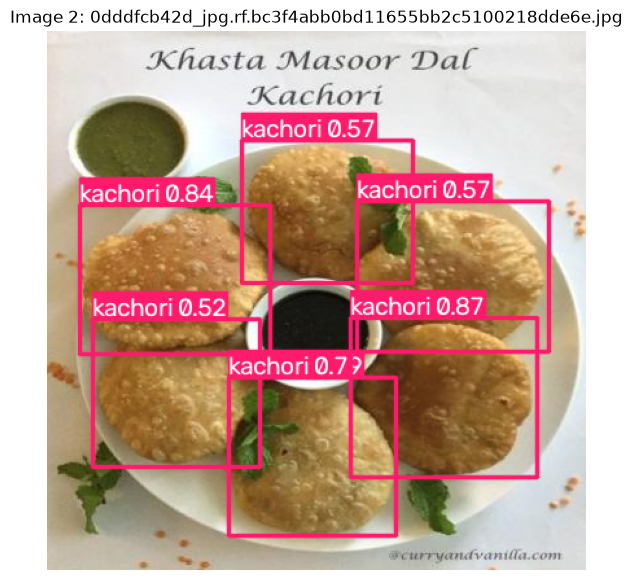

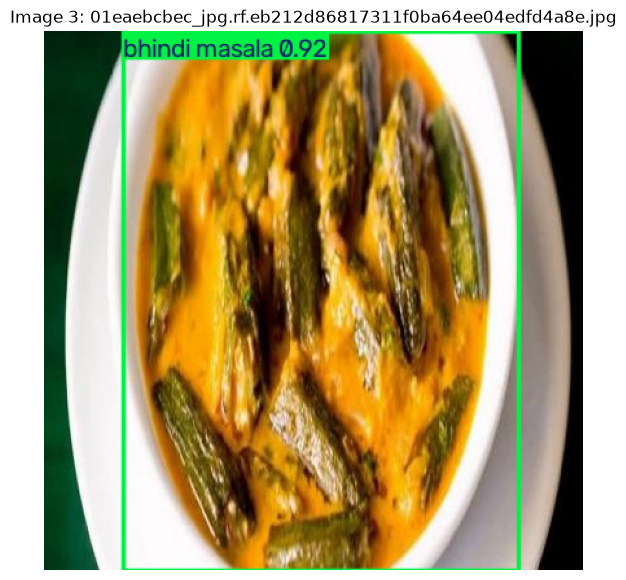

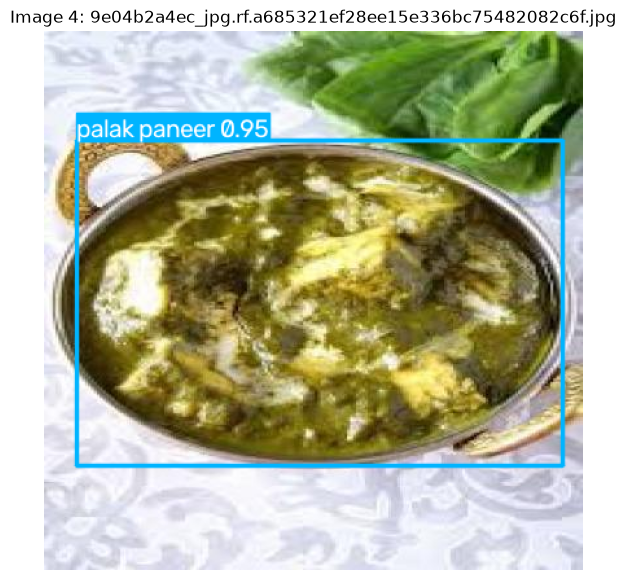

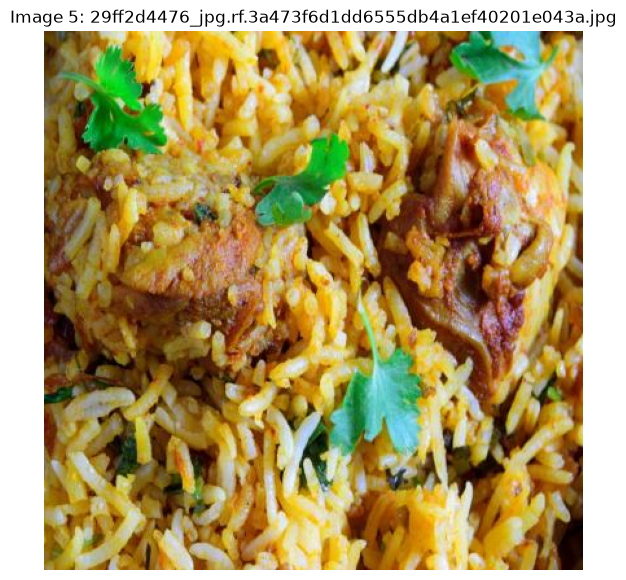

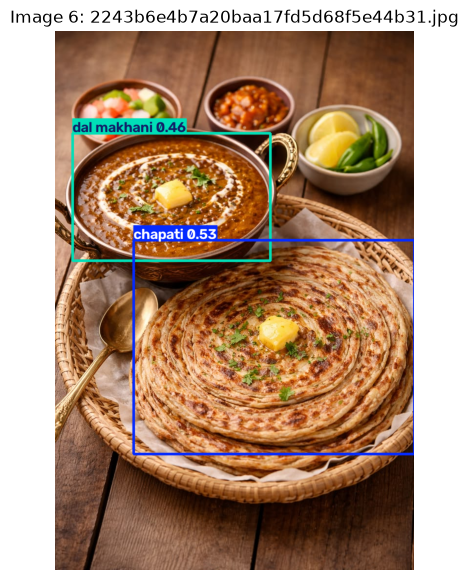

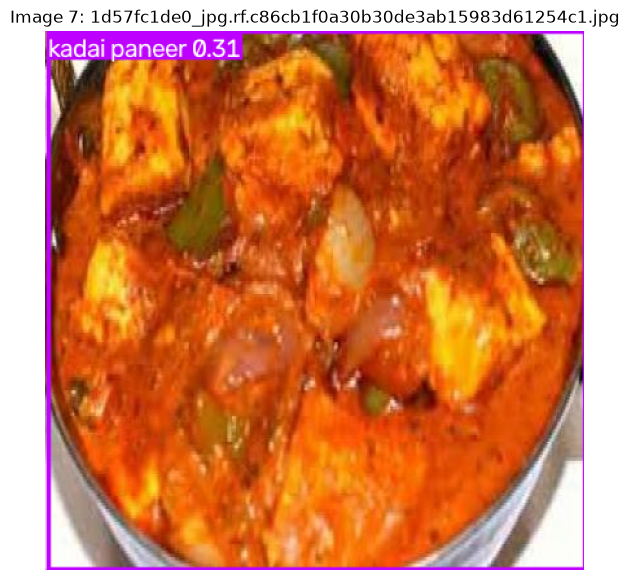

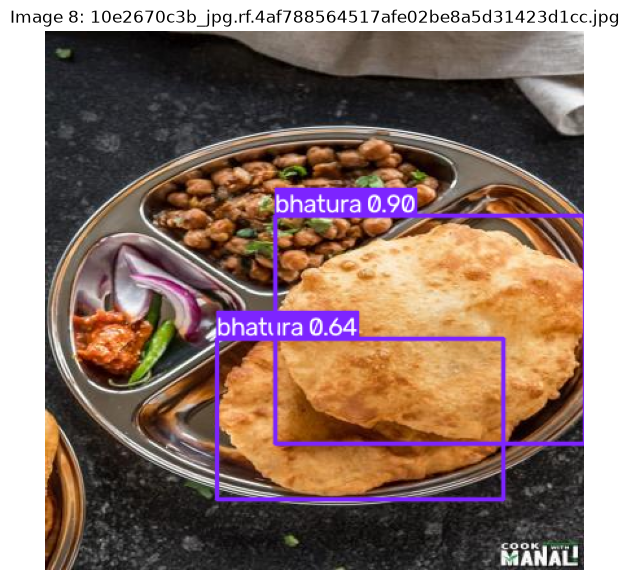

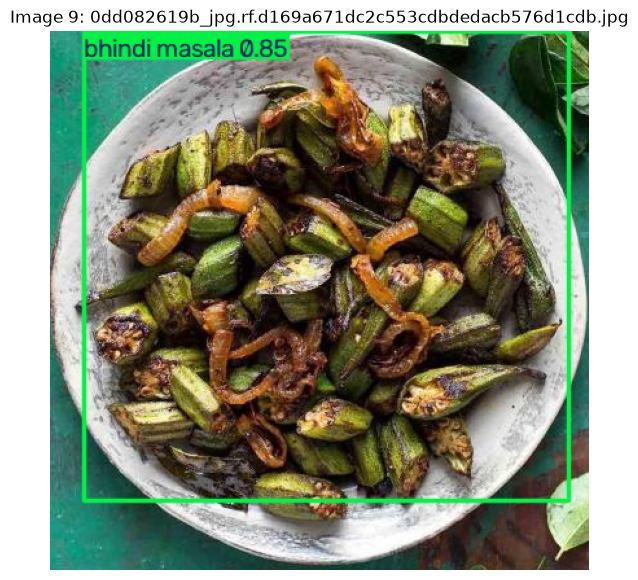

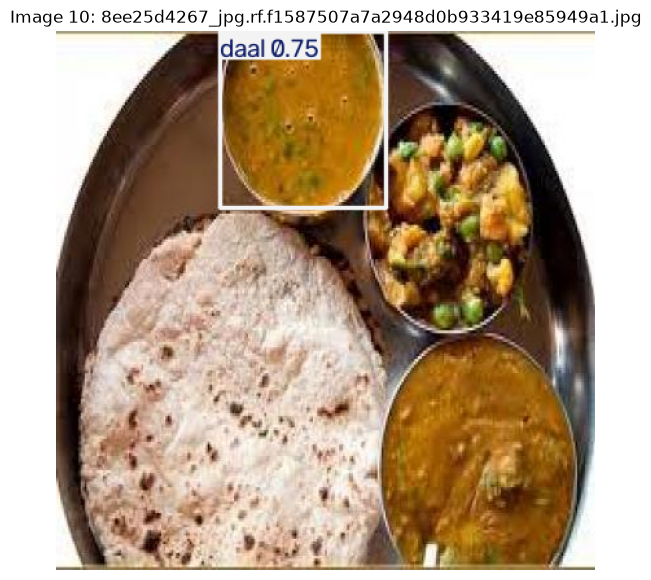

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

for i, result in enumerate(results):

    result_image = result.plot()

    plt.figure(figsize=(10, 7))
    plt.imshow(result_image[..., ::-1])
    plt.title(f"Image {i+1}: {sample_images[i].name}")
    plt.axis("off")
    plt.show()

In [ ]:
``